In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

## Importing Dataset

In [2]:
num_classes= 3

In [3]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Potato"
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 8286 files belonging to 3 classes.
Using 6629 files for training.
Found 8286 files belonging to 3 classes.
Using 1657 files for validation.
Training dataset size: 208 batches
Validation dataset size: 26 batches
Test dataset size: 26 batches


In [4]:
class_names = train_dataset.class_names
class_names

['Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight']

## Visualize some Image

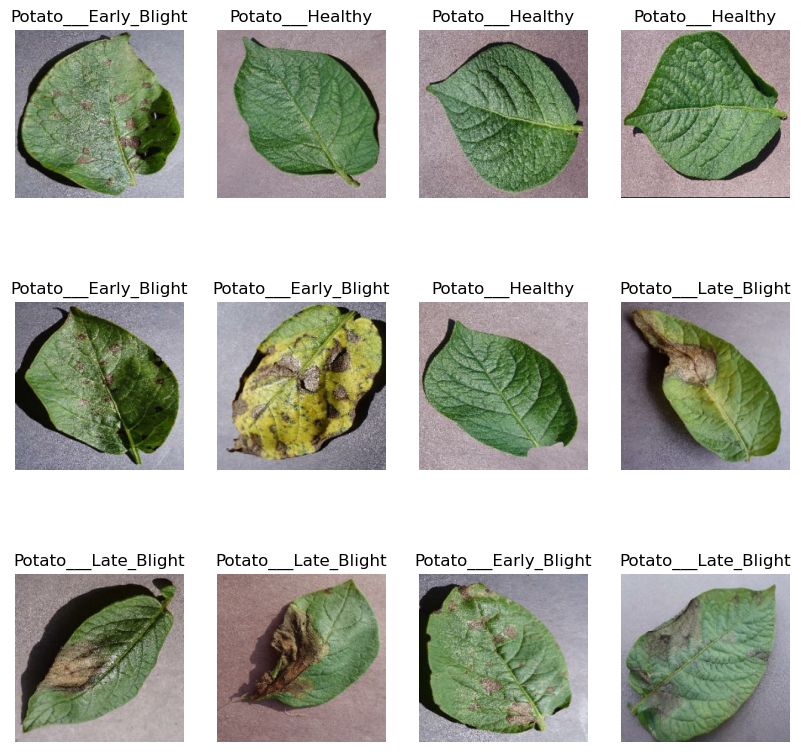

In [5]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

## Number of sapmple per class

C:\Users\NAHID\AppData\Local\Temp\ipykernel_12384\2432035227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Potato___Early_Blight","Potato___Healthy","Potato___Late_Blight"], y=Data_imbalance, palette="rocket")


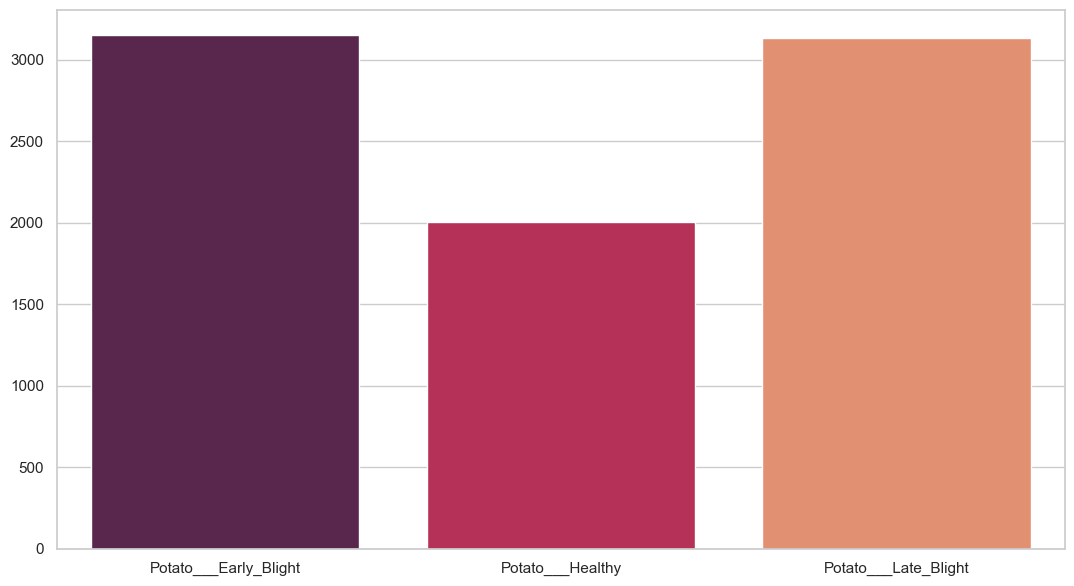

In [6]:
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=["Potato___Early_Blight","Potato___Healthy","Potato___Late_Blight"], y=Data_imbalance, palette="rocket")
plt.show()

In [7]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))

Weight for class 0: 0.66
Weight for class 1: 1.03
Weight for class 2: 0.66


## Data Augmentation

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [9]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

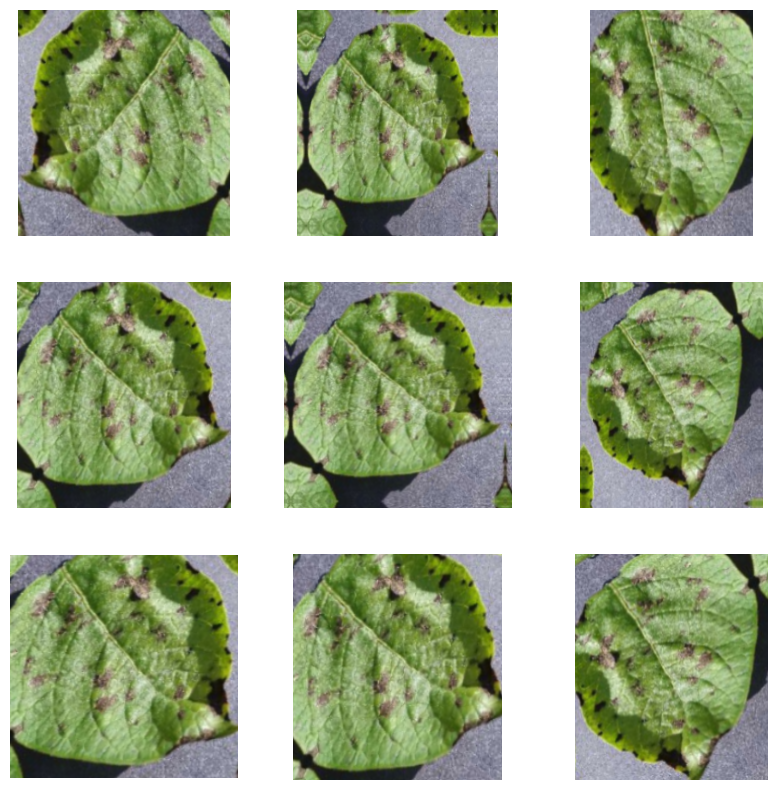

In [10]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

In [11]:
test=test_dataset

## Normalization

In [12]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

## Deit

In [13]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras import Model
import kagglehub
import tensorflow_hub as hub

In [19]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Load DeiT model
deit_path = kagglehub.model_download("spsayakpaul/deit/tensorFlow2/base-distilled-patch16-224")
deit_base = hub.KerasLayer(deit_path, trainable=False)

# Define SAM training step with tunable rho
def train_step_sam(model, data, rho=0.05):
    if len(data) == 3:
        x, y, sample_weight = data
    else:
        x, y = data
        sample_weight = None

    # First forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred, 
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    trainable_vars = model.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    
    # Calculate perturbation
    grad_norm = tf.linalg.global_norm(gradients)
    eps_w = [tf.math.multiply(g, rho / grad_norm) for g in gradients]
    
    # Apply perturbation
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_add(eps)
    
    # Second forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred,
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    gradients = tape.gradient(loss, trainable_vars)
    
    # Remove perturbation and apply gradients
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_sub(eps)
    
    model.optimizer.apply_gradients(zip(gradients, trainable_vars))
    
    # Update metrics
    model.compiled_metrics.update_state(y, y_pred, sample_weight=sample_weight)
    return {m.name: m.result() for m in model.metrics}

# Define custom DeiT model with SAM
class MyDeiT(tf.keras.Model):
    def __init__(self, deit_base, data_augmentation, num_classes, rho):
        super(MyDeiT, self).__init__(name='DeiT')
        self.data_augmentation = data_augmentation
        self.resizing = layers.Resizing(224, 224)
        self.deit_base = deit_base
        self.dropout = layers.Dropout(0.5)
        self.dense1 = layers.Dense(128, activation='gelu', name='the_feature_layer')
        self.dense2 = layers.Dense(num_classes, activation='softmax')
        self.rho = rho

    def build(self, input_shape):
        super(MyDeiT, self).build(input_shape)
        self.deit_base.build(input_shape)

    def call(self, x):
        x = self.data_augmentation(x)
        x = self.resizing(x)
        x = self.deit_base(x, training=True)
        
        if isinstance(x, tuple):
            x = x[0]
            
        x = self.dropout(x)
        x = self.dense1(x)
        return self.dense2(x)

    def train_step(self, data):
        return train_step_sam(self, data, rho=self.rho)

# Define the model building function for Keras Tuner
def build_model(hp):
    rho = hp.Float('rho', min_value=0.01, max_value=0.1, step=0.01)
    model = MyDeiT(deit_base, data_augmentation=data_augmentation, num_classes=4, rho=rho)
    model.build((None, 224, 224, 3))
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Instantiate the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='my_dir',
    project_name='sam_rho_tuning'
)

# Display search space summary
tuner.search_space_summary()

# Perform the hyperparameter search
tuner.search(train_dataset, validation_data=validation_dataset, epochs=5)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best rho: {best_hps.get('rho')}")

# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
best_history = best_model.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Search space summary
Default search space size: 1
rho (Float)
{'default': 0.01, 'conditions': [], 'min_value': 0.01, 'max_value': 0.1, 'step': 0.01, 'sampling': None}
Best rho: 0.03
Epoch 1/10
208/208 [==============================] - 131s 562ms/step - loss: 0.2858 - accuracy: 0.8991 - val_loss: 0.0733 - val_accuracy: 0.9675
Epoch 2/10
208/208 [==============================] - 119s 569ms/step - loss: 0.1095 - accuracy: 0.9541 - val_loss: 0.0296 - val_accuracy: 0.9904
Epoch 3/10
208/208 [==============================] - 123s 591ms/step - loss: 0.0810 - accuracy: 0.9667 - val_loss: 0.0561 - val_accuracy: 0.9796
Epoch 4/10
208/208 [==============================] - 121s 584ms/step - loss: 0.0747 - accuracy: 0.9695 - val_loss: 0.0327 - val_accuracy: 0.9904
Epoch 5/10
208/208 [==============================] - 124s 598ms/step - loss: 0.0719 - accuracy: 0.9698 - val_loss: 0.0213 - val_accuracy: 0.9940
Epoch 6/10
208/208 [==============================] - 114s 549ms/step - loss: 0.0703 - a

In [15]:
print(f"Test dataset type: {type(test_dataset)}")

for image, label in test_dataset.take(1):
    print(f"Sample image shape: {image.shape}, Sample label shape: {label.shape}")

# Initialize empty lists to store true labels and predicted labels
y_true = []
y_pred_classes = []

# Iterate through the test dataset to collect the true labels and predictions
for images, labels in test_dataset:
    # Collect true labels (convert to numpy array)
    y_true.extend(labels.numpy())
    
    # Make predictions using the model
    y_pred_prob = best_model(images, training=False)  # Model predictions (probabilities)
    
    # Convert predicted probabilities to class labels (argmax along the class axis)
    y_pred_classes.extend(tf.argmax(y_pred_prob, axis=1).numpy())

# Convert y_true and y_pred_classes to NumPy arrays for compatibility with sklearn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Ensure the shape of the true and predicted labels are consistent
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred_classes: {y_pred_classes.shape}")

# Now, you can compute the precision, recall, and f1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Test dataset type: <class 'tensorflow.python.data.ops.dataset_ops.ParallelMapDataset'>
Sample image shape: (32, 224, 224, 3), Sample label shape: (32,)
Shape of y_true: (825,)
Shape of y_pred_classes: (825,)
26/26 [==============================] - 5s 189ms/step - loss: 0.0280 - accuracy: 0.9927
Test Loss: 0.02803364396095276
Test Accuracy: 0.9927272796630859
Precision: 0.9928188674071027
Recall: 0.9927272727272727
F1-Score: 0.992716962586374


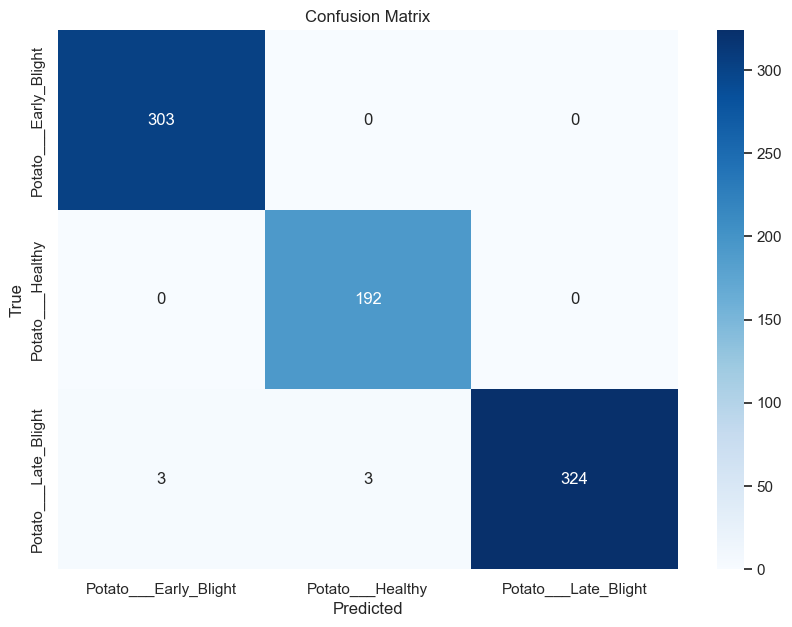

In [16]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

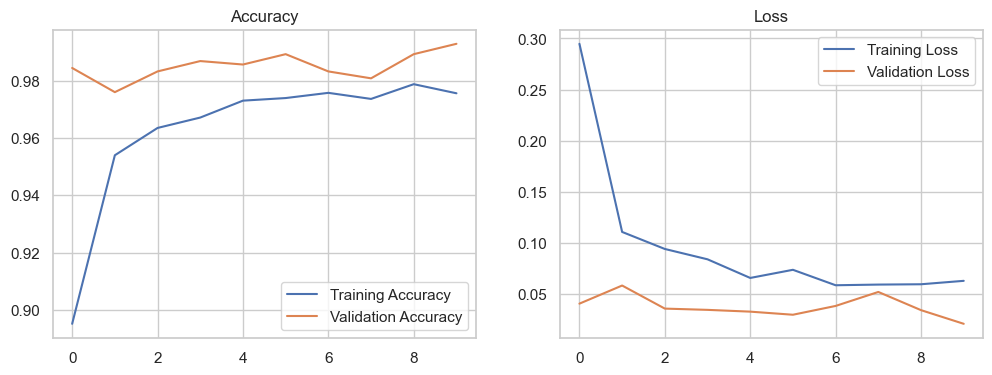

In [17]:
#Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [18]:
best_model.save("potato_deit_sam_model", save_format="tf")